In [8]:
from pathlib import Path
import os, inspect, json, hashlib, datetime, contextlib, io
import nbformat
from ai_data_scientist import project_manager, lifecycle, language_router
RUN_ID='v020-exp-47'
ROOT=Path('/home/nahisaho/GitHub/jupytermind')
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT']=str(ROOT/'benchmark/projects')
handle=project_manager.resolve_project('kaggle-v020-kaggle-exp-47-traffic-accidents')
project_manager.ensure_notebook(handle)
data_dir=project_manager.ensure_data_dir(handle)
language=language_router.detect_language('交通事故データを分析してください')
lifecycle.register_run(RUN_ID,handle.notebook_path)
phase_log=[]
@contextlib.contextmanager
def tracked(kind):
    if lifecycle.is_cancel_requested(RUN_ID): raise RuntimeError('run cancelled')
    getattr(lifecycle,'mark_'+kind+'_start')(RUN_ID)
    phase_log.append({'phase':kind,'event':'start','time':datetime.datetime.now(datetime.timezone.utc).isoformat()})
    try: yield
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        raise
    finally:
        getattr(lifecycle,'mark_'+kind+'_end')(RUN_ID)
        phase_log.append({'phase':kind,'event':'end','time':datetime.datetime.now(datetime.timezone.utc).isoformat()})
def append_cell(source,kind='code'):
    with tracked('write'):
        cell=nbformat.v4.new_code_cell(source) if kind=='code' else nbformat.v4.new_markdown_cell(source)
        project_manager.enqueue_write(handle,lambda nb: nb.cells.append(cell))
print('run_id',RUN_ID,'language',language,'notebook',str(handle.notebook_path))


run_id v020-exp-47 language ja notebook /home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-47-traffic-accidents/notebooks/kaggle-v020-kaggle-exp-47-traffic-accidents.ipynb


In [10]:
# Kaggle検索・認証（認証情報は一切出力しない）
acquisition_log=[]
api=None
search_results=[]
with tracked("execution"):
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api=KaggleApi()
            api.authenticate()
        acquisition_log.append({"step":"authenticate","ok":True})
        for query in ["traffic accidents weather", "road accident uk"]:
            results=api.dataset_list(search=query)
            rows=[{"slug":str(d.ref),"title":str(d.title),"bytes":getattr(d,"total_bytes",None)} for d in results[:12]]
            search_results.extend(rows)
            acquisition_log.append({"step":"dataset_list","query":query,"ok":True,"results":rows})
        print(json.dumps(acquisition_log,ensure_ascii=False,indent=2,default=str))
    except Exception as exc:
        acquisition_log.append({"step":"kaggle_acquisition","ok":False,"error_type":type(exc).__name__,"http_status":getattr(exc,"status",None)})
        print(json.dumps(acquisition_log,ensure_ascii=False,indent=2,default=str))
        print("Kaggle取得失敗。指定white-paperの同一データセットCSVのみ検討します。")


[
  {
    "step": "authenticate",
    "ok": true
  },
  {
    "step": "dataset_list",
    "query": "traffic accidents weather",
    "ok": true,
    "results": [
      {
        "slug": "denkuznetz/traffic-accident-prediction",
        "title": "Traffic Accident Prediction 💥🚗",
        "bytes": 10278
      },
      {
        "slug": "oktayrdeki/traffic-accidents",
        "title": "Traffic Accidents",
        "bytes": 4862299
      },
      {
        "slug": "devansodariya/road-accident-united-kingdom-uk-dataset",
        "title": "Road Accident (United Kingdom (UK)) Dataset",
        "bytes": 59533986
      },
      {
        "slug": "willianoliveiragibin/key-factors-traffic-accidents",
        "title": "Key Factors Traffic Accidents",
        "bytes": 244037
      },
      {
        "slug": "tsiaras/uk-road-safety-accidents-and-vehicles",
        "title": "UK Road Safety: Traffic Accidents and Vehicles",
        "bytes": 149163721
      },
      {
        "slug": "tanishqdublish/urban

In [14]:
slug="devansodariya/road-accident-united-kingdom-uk-dataset"
with tracked("execution"):
    listing=api.dataset_list_files(slug)
    listed_files=[{"name":f.name,"bytes":getattr(f,"total_bytes",None)} for f in listing.files]
    print("files",json.dumps(listed_files,ensure_ascii=False))


files [{"name": "UK_Accident.csv", "bytes": 449667447}]


In [16]:
with tracked("execution"):
    candidate="atharvasoundankar/road-accidents-dataset"
    candidate_listing=api.dataset_list_files(candidate)
    print("candidate files",[{"name":f.name,"bytes":getattr(f,"total_bytes",None)} for f in candidate_listing.files])
    for target in [slug,candidate]:
        target_dir=data_dir/target.split("/")[0]
        target_dir.mkdir(exist_ok=True)
        api.dataset_metadata(target,str(target_dir))
        for meta_path in target_dir.glob("*.json"):
            meta=json.loads(meta_path.read_text())
            print("metadata",target,json.dumps(meta,ensure_ascii=False,default=str)[:18000])


candidate files [{'name': 'Road Accident Data.csv', 'bytes': 69270104}]
metadata devansodariya/road-accident-united-kingdom-uk-dataset {"info": {"datasetId": 2219444, "datasetSlug": "road-accident-united-kingdom-uk-dataset", "ownerUser": "devansodariya", "usabilityRating": 0.9705882352941176, "totalViews": 41217, "totalVotes": 119, "totalDownloads": 8077, "title": "Road Accident (United Kingdom (UK)) Dataset", "subtitle": "Road Safety Dataset: UK Accident Dataset with 1.8m Record Including EDA Notebook", "description": "**Context**\nThe UK government amassed traffic data from 2000 and 2018, recording over 1.8 million accidents in the process and making this one of the most comprehensive traffic data sets out there. It's a huge picture of a country undergoing change.\n\n**Content**\nThere is 1 CSV File in this set. Accidents are the primary ones and have references by Accident_Index to the casualties and vehicles tables. This might be better done as a database.\n\n**Description**\nThis 

In [21]:
# データ取得・来歴・SHA-256
import zipfile
import pandas as pd
import numpy as np
from ai_data_scientist import ingestion, cleaning, eda, data_definition, analysis_assumptions, data_quality, sensitivity, visualization, notebook_audit, insight_engine
slug=candidate
filename="Road Accident Data.csv"
source_file=data_dir/filename
with tracked("execution"):
    from urllib.parse import quote
    encoded_file=data_dir/quote(filename,safe="")
    if not source_file.exists() and encoded_file.exists(): encoded_file.rename(source_file)
    if not source_file.exists():
        api.dataset_download_file(slug,filename,path=str(data_dir),quiet=True)
        if not source_file.exists() and encoded_file.exists(): encoded_file.rename(source_file)
        zipped=data_dir/(filename+".zip")
        if not source_file.exists() and zipped.exists():
            with zipfile.ZipFile(zipped) as archive:
                if filename not in archive.namelist(): raise RuntimeError("指定CSVがZIP内にありません")
                with archive.open(filename) as src, source_file.open("wb") as dst:
                    import shutil
                    shutil.copyfileobj(src,dst)
    digest=hashlib.file_digest(source_file.open("rb"),"sha256").hexdigest()
    receipt_path=data_dir/"acquisition-receipt.json"
    if receipt_path.exists():
        receipt=json.loads(receipt_path.read_text())
        if receipt["sha256"]!=digest or receipt["slug"]!=slug: raise RuntimeError("取得来歴とCSVが一致しません")
    else:
        receipt={"slug":slug,"file":filename,"retrieved_at":datetime.datetime.now(datetime.timezone.utc).isoformat(),"sha256":digest,"bytes":source_file.stat().st_size,"source":"Kaggle Python SDK dataset_download_file","url":"https://www.kaggle.com/datasets/"+slug}
        receipt_path.write_text(json.dumps(receipt,ensure_ascii=False,indent=2))
    print("provenance",json.dumps(receipt,ensure_ascii=False,indent=2))
    for module,names in [(ingestion,["ingest"]),(cleaning,["clean_dataset"]),(eda,["explore"]),(data_definition,["build_manifest","DataDefinitionManifest"]),(analysis_assumptions,["Assumption","AnalysisAssumptionManifest","check_manifest"]),(data_quality,["detect_anomalies"]),(sensitivity,["SensitivityPlan","run_sensitivity"]),(visualization,["render_chart","build_image_output"]),(notebook_audit,["audit_notebook"]),(insight_engine,["record_insight","extract_cited_value"])]:
        for name in names: print(module.__name__,name,str(inspect.signature(getattr(module,name))))
    raw=pd.read_csv(source_file,low_memory=False)
    print("shape",raw.shape,"columns",raw.columns.tolist())
    display(raw.head(3))
    for c in raw.columns:
        if c in ["Accident_Severity","Weather_Conditions","Road_Type","Time","Accident_Date","Date","Light_Conditions","Urban_or_Rural_Area"]:
            print(c,raw[c].value_counts(dropna=False).head(12).to_dict())


provenance {
  "slug": "atharvasoundankar/road-accidents-dataset",
  "file": "Road Accident Data.csv",
  "retrieved_at": "2026-10-01T23:26:25.707177+00:00",
  "sha256": "6d870f4b258953d93d0f3978dde5ecc739ec5ebf27c4986b260426aa8da9617d",
  "bytes": 69270104,
  "source": "Kaggle Python SDK dataset_download_file",
  "url": "https://www.kaggle.com/datasets/atharvasoundankar/road-accidents-dataset"
}
ai_data_scientist.ingestion ingest (source_spec: 'SourceSpec', fetcher=None, allowlist: 'tuple[str, ...]' = (), row_limit: 'int' = 100000) -> 'IngestionResult'
ai_data_scientist.cleaning clean_dataset (df: 'pd.DataFrame', operation: 'str', columns: 'list | None' = None, fill_value=None) -> 'CleaningReport'
ai_data_scientist.eda explore (df: 'pd.DataFrame', top_n: 'int' = 10) -> 'EDAReport'
ai_data_scientist.data_definition build_manifest (source: 'dict', dataset_scope: 'dict', variables: 'dict[str, dict[str, FieldValue]]', transformations: 'tuple' = ()) -> 'DataDefinitionManifest'
ai_data_scien

,Accident_Index,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,BS0000001,01-01-2021,Thursday,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,BS0000002,05-01-2021,Monday,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,Kensington and Chelsea,NaN,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,BS0000003,04-01-2021,Sunday,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car


In [23]:
# 読込み・重複・意味的データ品質の一次点検
import dataclasses
with tracked("execution"):
    print("FieldValue",inspect.signature(data_definition.FieldValue))
    print("SourceSpec",inspect.signature(ingestion.SourceSpec))
    clean_report=cleaning.clean_dataset(raw,operation="drop_duplicates")
    print("clean report fields",[(f.name,str(f.type)) for f in dataclasses.fields(clean_report)])
    print("exact duplicate rows",int(raw.duplicated().sum()),"repeated accident IDs",int(raw.Accident_Index.duplicated().sum()),"unique IDs",raw.Accident_Index.nunique())
    eda_report=eda.explore(raw,top_n=8)
    print("EDA fields",[(f.name,str(f.type)) for f in dataclasses.fields(eda_report)])
    print("missing counts",raw.isna().sum().to_dict())
    dates=pd.to_datetime(raw["Accident Date"],format="%d-%m-%Y",errors="coerce")
    print("dates",str(dates.min()),str(dates.max()),"by year",dates.dt.year.value_counts(dropna=False).to_dict())
    print("weekday mismatch",int(dates.dt.day_name().ne(raw.Day_of_Week).sum()))
    print("lat_lon summary",raw[["Latitude","Longitude"]].describe().to_dict())
    print("method docs",data_definition.build_manifest.__doc__,ingestion.ingest.__doc__,visualization.build_image_output.__doc__)


FieldValue (value: 'object', status: 'str', source: 'str | None' = None) -> None
SourceSpec (kind: 'str', location: 'str') -> None
clean report fields [('dataframe', 'pd.DataFrame'), ('rows_before', 'int'), ('rows_after', 'int'), ('rows_removed', 'int'), ('columns_affected', 'list')]
exact duplicate rows 0 repeated accident IDs 0 unique IDs 307973
EDA fields [('describe', 'dict'), ('dtypes', 'dict'), ('non_null_counts', 'dict'), ('missing_summary', 'dict'), ('categorical_summary', 'dict')]
missing counts {'Accident_Index': 0, 'Accident Date': 0, 'Day_of_Week': 0, 'Junction_Control': 0, 'Junction_Detail': 0, 'Accident_Severity': 0, 'Latitude': 0, 'Light_Conditions': 0, 'Local_Authority_(District)': 0, 'Carriageway_Hazards': 302549, 'Longitude': 0, 'Number_of_Casualties': 0, 'Number_of_Vehicles': 0, 'Police_Force': 0, 'Road_Surface_Conditions': 0, 'Road_Type': 0, 'Speed_limit': 0, 'Time': 17, 'Urban_or_Rural_Area': 0, 'Weather_Conditions': 0, 'Vehicle_Type': 0}
dates 2021-01-01 00:00:00 

In [25]:
# データ定義・分析前提manifestと意味的異常検査
with tracked("execution"):
    loaded=ingestion.ingest(ingestion.SourceSpec(kind="csv",location=str(source_file)),row_limit=400000)
    print("ingestion",[(f.name,str(f.type)) for f in dataclasses.fields(loaded)])
    df=clean_report.dataframe.copy()
    print("cleaning",{"rows_before":clean_report.rows_before,"rows_after":clean_report.rows_after,"rows_removed":clean_report.rows_removed,"columns_affected":clean_report.columns_affected})
    fv=data_definition.FieldValue
    variables={
      "Accident_Index":{"definition":fv("CSV内で一意の事故識別子","verified","セル5の重複検査"),"unit":fv("1行=1記録。元の事故表との一致は未検証","inferred")},
      "Accident_Severity":{"definition":fv("Slight / Serious / Fatal。Fetalは未定義ラベル","inferred","CSVのラベル"),"unit":fv("事故単位の重大度。臨床的・警察的基準は未確認","unknown")},
      "Time":{"definition":fv("HH:MM形式の記録時刻","inferred"),"timezone":fv("現地時刻と推測。DST・UTC変換不明","unknown")},
      "Accident Date":{"definition":fv("日-月-年形式。全行で曜日と矛盾するため実年代は採用しない","inferred")},
      "Road_Type":{"definition":fv("道路形状カテゴリ。道路名や区間識別子ではない","inferred")},
      "Weather_Conditions":{"definition":fv("事故時の天候カテゴリ。観測地点・判定法不明","inferred")},
      "Latitude":{"unit":fv("緯度（度）と推測","inferred"),"coordinate_reference_system":fv("測地系不明","unknown")},
      "Longitude":{"unit":fv("経度（度）と推測","inferred"),"coordinate_reference_system":fv("測地系不明","unknown")},
      "Speed_limit":{"unit":fv("UKのmphと推測するが辞書未確認。層別用の数値コードのみ使用","inferred")},
      "exposure":{"definition":fv("交通量・走行距離・道路延長・天候の継続時間はない","verified","全21列の確認")}}
    definition_manifest=data_definition.build_manifest(source={"receipt":receipt,"publisher_statement":"DfT由来・加工済みとKaggle投稿者が記載。原本との一致は未検証"},dataset_scope={"observed_records":len(df),"geographic_scope":"UKと投稿者が記載。抽出・前処理ルール不明","recorded_dates":"2021/2022ラベル。実年代は未確定"},variables=variables,transformations=("完全重複を除去（実際の除去0行）","重大度Fetalは主分析から除外","時刻欠損は件数全体には保持、時間帯表からのみ除外"))
    print("definition manifest",json.dumps(dataclasses.asdict(definition_manifest),ensure_ascii=False,default=str))
    print("unresolved fields",definition_manifest.unresolved_fields())
    assumptions=analysis_assumptions.AnalysisAssumptionManifest(analysis_scope={"target":"このCSVに記録された事故の件数・重傷死亡割合の比較"},causal_scope="descriptive",sampling={"n":len(df),"seed":None,"kind":"公開済み加工サブセットの全行","representativeness":"不明"},assumptions=(
        analysis_assumptions.Assumption("unique-record","1行を1事故記録として集計", "tested",impact_if_false="件数の過大計上",conclusion_critical=True),
        analysis_assumptions.Assumption("severity-label","Serious/Fatalを重傷死亡ラベルと解釈", "assumed",impact_if_false="臨床的・統計的重大度の解釈に誤り",conclusion_critical=True),
        analysis_assumptions.Assumption("time-local","Timeが事故時の現地時刻", "assumed",impact_if_false="時間帯の意味が変わる",conclusion_critical=True),
        analysis_assumptions.Assumption("national-representative","全国の全事故を代表", "rejected",impact_if_false="全国への一般化不可",conclusion_critical=True),
        analysis_assumptions.Assumption("true-calendar","記載年と曜日が整合", "rejected",impact_if_false="年代・曜日別の実世界推論不可",conclusion_critical=True),
        analysis_assumptions.Assumption("causal-identification","曝露量・交絡・記録選択を統制した因果効果", "rejected",impact_if_false="因果結論不可",conclusion_critical=True)))
    assumption_findings=analysis_assumptions.check_manifest(assumptions)
    print("analysis assumptions",json.dumps(dataclasses.asdict(assumptions),ensure_ascii=False,default=str))
    print("assumption findings",[dataclasses.asdict(f) for f in assumption_findings])
    valid_time=df.Time.str.fullmatch(r"(?:[01]\d|2[0-3]):[0-5]\d",na=False)
    df["hour"]=pd.to_numeric(df.Time.where(valid_time).str.slice(0,2),errors="coerce")
    df["recorded_year"]=dates.dt.year
    df["geo_missing"]=df[["Latitude","Longitude"]].isna().any(axis=1)
    df["geo_valid"]=df.Latitude.between(49,61)&df.Longitude.between(-9,2.5)&~df.geo_missing
    semantic_records=data_quality.detect_anomalies(df,schema={"Accident_Index":{"not_null":True,"unique":True},"Accident_Severity":{"allowed":["Slight","Serious","Fatal"],"not_null":True},"Latitude":{"min":-90,"max":90,"not_null":True},"Longitude":{"min":-180,"max":180,"not_null":True},"Number_of_Casualties":{"min":1},"Number_of_Vehicles":{"min":1},"Speed_limit":{"allowed":[10,15,20,30,40,50,60,70]},"hour":{"min":0,"max":23},"Road_Type":{"allowed":["Single carriageway","Dual carriageway","Roundabout","One way street","Slip road"]}})
    print("semantic anomalies",[dataclasses.asdict(r) for r in semantic_records])
    semantic_summary={"invalid_or_missing_time":int((~valid_time).sum()),"weekday_mismatch":int(dates.dt.day_name().ne(df.Day_of_Week).sum()),"geo_missing":int(df.geo_missing.sum()),"geo_outside_plausible_UK_box":int((~df.geo_valid).sum()),"zero_coordinates":int((df.Latitude.eq(0)|df.Longitude.eq(0)).sum()),"unknown_severity":int((~df.Accident_Severity.isin(["Slight","Serious","Fatal"])).sum()),"repeated_coordinate_rows":int(df.duplicated(["Latitude","Longitude"],keep=False).sum())}
    print("SEMANTIC_SUMMARY",json.dumps(semantic_summary))
    print("EDA missing",json.dumps(eda_report.missing_summary,ensure_ascii=False,default=str))
    print("EDA categorical",json.dumps({c:eda_report.categorical_summary[c] for c in ["Accident_Severity","Road_Type","Weather_Conditions"]},ensure_ascii=False,default=str))


ingestion [('dataframe', 'pd.DataFrame'), ('row_count', 'int'), ('column_count', 'int'), ('truncated', 'bool')]
cleaning {'rows_before': 307973, 'rows_after': 307973, 'rows_removed': 0, 'columns_affected': ['Accident_Index', 'Accident Date', 'Day_of_Week', 'Junction_Control', 'Junction_Detail', 'Accident_Severity', 'Latitude', 'Light_Conditions', 'Local_Authority_(District)', 'Carriageway_Hazards', 'Longitude', 'Number_of_Casualties', 'Number_of_Vehicles', 'Police_Force', 'Road_Surface_Conditions', 'Road_Type', 'Speed_limit', 'Time', 'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type']}
definition manifest {"source": {"receipt": {"slug": "atharvasoundankar/road-accidents-dataset", "file": "Road Accident Data.csv", "retrieved_at": "2026-10-01T23:26:25.707177+00:00", "sha256": "6d870f4b258953d93d0f3978dde5ecc739ec5ebf27c4986b260426aa8da9617d", "bytes": 69270104, "source": "Kaggle Python SDK dataset_download_file", "url": "https://www.kaggle.com/datasets/atharvasoundankar/road-acc

In [28]:
# 初回分析：件数と記録事故内の重傷死亡割合（曝露率ではない）
def group_table(frame,col):
    working=frame.copy()
    working["known"]=working.Accident_Severity.isin(["Slight","Serious","Fatal"])
    working["severe"]=working.Accident_Severity.isin(["Serious","Fatal"])
    working["fatal"]=working.Accident_Severity.eq("Fatal")
    out=working.groupby(col,observed=True,dropna=False).agg(records=("Accident_Index","size"),known=("known","sum"),severe=("severe","sum"),fatal=("fatal","sum"))
    out["unknown"]=out.records-out.known
    p=out.severe/out.known
    z=1.959963984540054
    center=(p+z*z/(2*out.known))/(1+z*z/out.known)
    half=z*np.sqrt(p*(1-p)/out.known+z*z/(4*out.known**2))/(1+z*z/out.known)
    out["severe_pct"]=100*p
    out["wilson_low_pct"]=100*(center-half)
    out["wilson_high_pct"]=100*(center+half)
    out["fatal_pct"]=100*out.fatal/out.known
    return out
with tracked("execution"):
    df["clock_band"]=pd.cut(df.hour,bins=[-1,3,7,11,15,19,23],labels=["00-03","04-07","08-11","12-15","16-19","20-23"])
    hourly=group_table(df.loc[df.hour.notna()],"hour")
    bands=group_table(df.loc[df.hour.notna()],"clock_band")
    roads=group_table(df,"Road_Type").sort_values("records",ascending=False)
    weather=group_table(df,"Weather_Conditions").sort_values("records",ascending=False)
    areas=group_table(df,"Urban_or_Rural_Area")
    for name,table in [("HOUR",hourly),("BAND",bands),("ROAD",roads),("WEATHER",weather),("AREA",areas)]:
        print(name);print(table.to_string(float_format=lambda v:f"{v:.6f}"))
    total_known=int(df.Accident_Severity.isin(["Slight","Serious","Fatal"]).sum())
    initial_summary={"records":len(df),"known_severity":total_known,"unknown_severity":len(df)-total_known,"severe":int(df.Accident_Severity.isin(["Serious","Fatal"]).sum()),"severe_pct":100*df.Accident_Severity.isin(["Serious","Fatal"]).sum()/total_known,"peak_hour":int(hourly.records.idxmax()),"peak_hour_records":int(hourly.records.max()),"max_severe_hour":int(hourly.severe_pct.idxmax()),"max_severe_hour_pct":float(hourly.severe_pct.max()),"fine_pct":float(weather.loc["Fine no high winds","severe_pct"]),"rain_pct":float(weather.loc["Raining no high winds","severe_pct"])}
    print("INITIAL_SUMMARY",json.dumps(initial_summary,ensure_ascii=False))
    print("注意：recordsは記録件数、severe_pctは重大度既知の記録事故を分母にした構成割合。走行距離・交通量・天候の発生時間を分母とした事故率ではない。Wilson区間は独立な二項記録過程を仮定した参考値で、選択バイアスや定義誤りを含まない。")


HOUR
      records  known  severe  fatal  unknown  severe_pct  wilson_low_pct  wilson_high_pct  fatal_pct
hour                                                                                                
0.0      4667   4666     995    146        1   21.324475       20.173048        22.523079   3.129018
1.0      3533   3533     760    119        0   21.511463       20.187866        22.896945   3.368242
2.0      2652   2652     630    101        0   23.755656       22.174591        25.412642   3.808446
3.0      2311   2311     533     81        0   23.063609       21.391729        24.824891   3.504976
4.0      1721   1720     413     62        1   24.011628       22.052277        26.086806   3.604651
5.0      2491   2491     509     85        0   20.433561       18.896223        22.061949   3.412284
6.0      5274   5271     899    112        3   17.055587       16.064286        18.094873   2.124834
7.0     12560  12560    1783    163        0   14.195860       13.596439        14.817

chart metadata [{}, {}, {}, {}, {}, {}]
図の棒は0起点。天候・道路のラベルは元データの英語表記。95%参考区間と分母は集計表で確認。件数の大小を事故発生率と解釈しない。


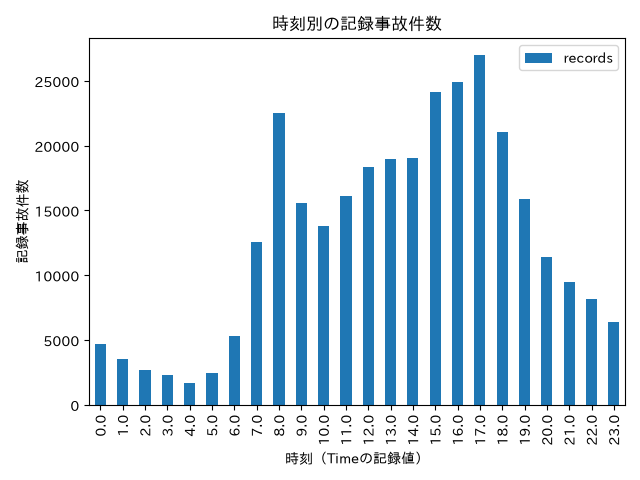

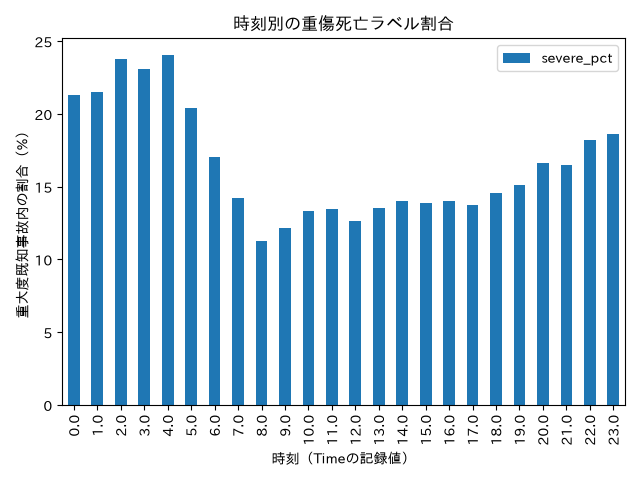

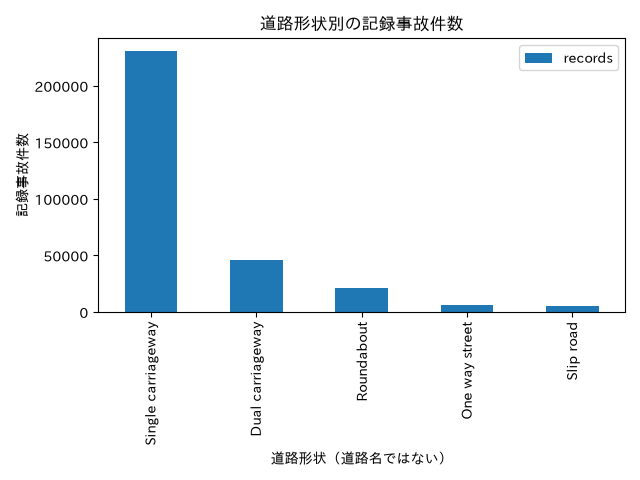

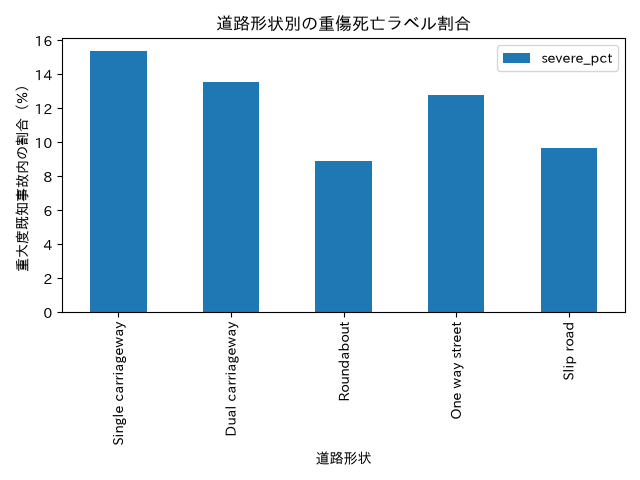

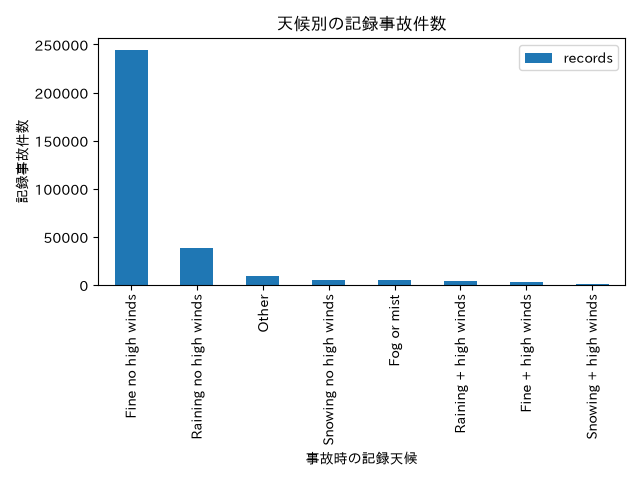

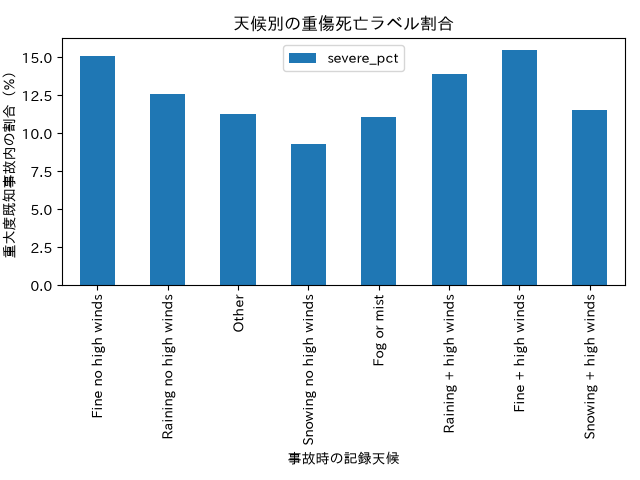

In [41]:
# 図表：件数と構成割合を別々の軸で表示
import matplotlib.pyplot as plt
import base64
chart_outputs=[]
with tracked("execution"):
    chart_specs=[(hourly.reset_index(),"hour","records","時刻別の記録事故件数","時刻（Timeの記録値）","記録事故件数"),(hourly.reset_index(),"hour","severe_pct","時刻別の重傷死亡ラベル割合","時刻（Timeの記録値）","重大度既知事故内の割合（%）"),(roads.reset_index(),"Road_Type","records","道路形状別の記録事故件数","道路形状（道路名ではない）","記録事故件数"),(roads.reset_index(),"Road_Type","severe_pct","道路形状別の重傷死亡ラベル割合","道路形状","重大度既知事故内の割合（%）"),(weather.reset_index(),"Weather_Conditions","records","天候別の記録事故件数","事故時の記録天候","記録事故件数"),(weather.reset_index(),"Weather_Conditions","severe_pct","天候別の重傷死亡ラベル割合","事故時の記録天候","重大度既知事故内の割合（%）")]
    before_spec=chart_specs[4]
    with plt.rc_context({"figure.autolayout":False}):
        before_png=visualization.render_chart(before_spec[0],kind="bar",x=before_spec[1],y=before_spec[2],title=before_spec[3],xlabel=before_spec[4],ylabel=before_spec[5])
    (data_dir/"visual-layout-before.png").write_bytes(before_png)
    for table,x,y,title,xlabel,ylabel in chart_specs:
        with plt.rc_context({"figure.autolayout":True}):
            png=visualization.render_chart(table,kind="bar",x=x,y=y,title=title,xlabel=xlabel,ylabel=ylabel)
        output=visualization.build_image_output(png)
        chart_outputs.append(output)
        display(output.data,raw=True,metadata=output.get("metadata",{}))
    (data_dir/"visual-layout-after.png").write_bytes(base64.b64decode(chart_outputs[4].data["image/png"]))
    print("LAYOUT_LOG",{"before_sha256":hashlib.sha256(before_png).hexdigest(),"after_sha256":hashlib.sha256(base64.b64decode(chart_outputs[4].data["image/png"])).hexdigest(),"workaround":"figure.autolayout=True","initial_audit_visual_findings":[]})
    print("chart metadata",[o.get("metadata",{}) for o in chart_outputs])
    print("図の棒は0起点。天候・道路のラベルは元データの英語表記。95%参考区間と分母は集計表で確認。件数の大小を事故発生率と解釈しない。")


## 反復依頼履歴

### 反復1 — 追加依頼の原文
日付と曜日の全件不一致について、日月の取り違え・一定日数ずれを検査し、元の年代を推測で補正せず、年代のラベルに依存しない結論と位置情報欠損・時刻欠損による影響を確認してください。

**選定理由：** 初回の意味的異常検査で暦の整合性が成立しなかった。年代解釈と記録の加工可能性は結論の外的妥当性に実質的に影響する。CSV内の緯度経度欠損ゼロが、収集時の欠損ゼロを意味するかも切り分ける。


In [33]:
# 反復1：暦矛盾と位置・時刻欠損の影響
with tracked("execution"):
    offset_matches={offset:int((dates+pd.Timedelta(days=offset)).dt.day_name().eq(df.Day_of_Week).sum()) for offset in range(-3,4)}
    swapped=pd.to_datetime(df["Accident Date"],format="%m-%d-%Y",errors="coerce")
    calendar_checks={"strict_dd_mm_valid":int(dates.notna().sum()),"dd_mm_weekday_matches":int(dates.dt.day_name().eq(df.Day_of_Week).sum()),"mm_dd_parseable":int(swapped.notna().sum()),"mm_dd_weekday_matches":int(swapped.dt.day_name().eq(df.Day_of_Week).sum()),"offset_day_matches":offset_matches}
    missing_time=group_table(df.assign(time_missing=df.hour.isna()),"time_missing")
    location_check=group_table(df,"geo_missing")
    nonempty_location_strings={c:int(df[c].astype(str).str.strip().eq("").sum()) for c in ["Latitude","Longitude"]}
    time_missing_max_shift_pp=100*int(df.hour.isna().sum())/float(hourly.known.min())
    top_hours=hourly.records.sort_values(ascending=False).head(2)
    peak_robust=int(top_hours.iloc[0]-top_hours.iloc[1])>int(df.hour.isna().sum())
    location_summary={"rows":len(df),"geo_missing":int(df.geo_missing.sum()),"geo_invalid":int((~df.geo_valid).sum()),"unique_coordinates":int(df[["Latitude","Longitude"]].drop_duplicates().shape[0]),"shared_coordinate_rows":int(df.duplicated(["Latitude","Longitude"],keep=False).sum()),"districts":int(df["Local_Authority_(District)"].nunique()),"police_forces":int(df.Police_Force.nunique()),"empty_strings":nonempty_location_strings}
    print("CALENDAR_CHECKS",json.dumps(calendar_checks));print("LOCATION_CHECKS",json.dumps(location_summary))
    print("TIME_MISSING");print(missing_time.to_string())
    print("PEAK_ROBUST_TO_MISSING_TIME",peak_robust,"max_conservative_hour_pct_shift_pp",time_missing_max_shift_pp)
    print("反復1結果：暦の矛盾は未解決。一定ずれと曜日整合があっても事故日を補正する根拠にはならない。記載年は加工後ラベルとして扱う。位置情報はCSV内では欠損・範囲外なし。ただしKaggle投稿者による事前除外・補完の有無は不明。座標の共有は同地点の別事故でも起きるため重複として削除しない。位置欠損あり群との比較は群が存在しないため適用不可。")


CALENDAR_CHECKS {"strict_dd_mm_valid": 307973, "dd_mm_weekday_matches": 0, "mm_dd_parseable": 122977, "mm_dd_weekday_matches": 17240, "offset_day_matches": {"-3": 0, "-2": 0, "-1": 307973, "0": 0, "1": 0, "2": 0, "3": 0}}
LOCATION_CHECKS {"rows": 307973, "geo_missing": 0, "geo_invalid": 0, "unique_coordinates": 280808, "shared_coordinate_rows": 46957, "districts": 422, "police_forces": 51, "empty_strings": {"Latitude": 0, "Longitude": 0}}
TIME_MISSING
              records   known  severe  fatal  unknown  severe_pct  wilson_low_pct  wilson_high_pct  fatal_pct
time_missing                                                                                                 
False          307956  307907   44642   3904       49   14.498534       14.374615        14.623338   1.267915
True               17      17       2      0        0   11.764706        3.287977        34.336351   0.000000
PEAK_ROBUST_TO_MISSING_TIME True max_conservative_hour_pct_shift_pp 0.9883720930232558
反復1結果：暦の矛盾は未解決。一定

### 反復2 — 追加依頼の原文
晴天より降雨で重大度割合が低い点が都市・郊外、道路形状、時間帯、速度制限の構成差によるものか、共通サポートの層別標準化で検証してください。死亡のみの場合と記録年ラベルごとの結果も比較し、因果効果とは解釈しないでください。

**選定理由：** 初回表では無強風の晴天より降雨の重傷死亡割合が低かった。これを「雨のほうが安全」と誤読しないよう、観測された構成差とアウトカム定義への依存を調べる。年は実年代でなく加工後ラベルとしてのみ用いる。


In [35]:
# 反復2：共通サポートでの層別標準化
def prepare_outcome(unknown="exclude",outcome="severe",year="all"):
    cols=["Accident_Severity","hour","clock_band","Road_Type","Urban_or_Rural_Area","Weather_Conditions","Speed_limit","recorded_year"]
    work=df[cols].copy()
    if year!="all": work=work.loc[work.recorded_year.eq(int(year))].copy()
    known=work.Accident_Severity.isin(["Slight","Serious","Fatal"])
    if unknown=="exclude": work=work.loc[known].copy()
    elif unknown not in ["nonsevere","severe"]: raise ValueError("unknown policy")
    work["outcome"]=work.Accident_Severity.isin(["Serious","Fatal"]) if outcome=="severe" else work.Accident_Severity.eq("Fatal")
    if unknown=="severe": work.loc[work.Accident_Severity.eq("Fetal"),"outcome"]=True
    return work
def standardize(work,group_col,groups,strata,min_n=20):
    selected=work.loc[work[group_col].isin(groups)].dropna(subset=strata+["outcome"]).copy()
    summary=selected.groupby(strata+[group_col],observed=True).outcome.agg(["size","mean"]).unstack(group_col)
    counts=summary["size"].reindex(columns=groups)
    rates=summary["mean"].reindex(columns=groups)
    common=counts.ge(min_n).all(axis=1)
    if not common.any(): raise ValueError("共通サポートなし")
    pooled=counts.loc[common].sum(axis=1)
    weights=pooled/pooled.sum()
    adjusted=(rates.loc[common].mul(weights,axis=0)).sum()*100
    crude=selected.groupby(group_col).outcome.mean().reindex(groups)*100
    coverage=(counts.loc[common].sum()/selected[group_col].value_counts().reindex(groups))*100
    return {"groups":groups,"strata":strata,"min_per_group":min_n,"common_strata":int(common.sum()),"retained_records":int(pooled.sum()),"selected_records":len(selected),"coverage_pct":coverage.to_dict(),"crude_pct":crude.to_dict(),"standardized_pct":adjusted.to_dict(),"difference_pp":float(adjusted.iloc[1]-adjusted.iloc[0])}
def weather_comparison(unknown="exclude",outcome="severe",year="all",wind="exclude",min_n=20):
    work=prepare_outcome(unknown,outcome,year)
    if wind=="exclude":
        work["weather_group"]=work.Weather_Conditions.map({"Fine no high winds":"fine","Raining no high winds":"rain"})
    elif wind=="include":
        work["weather_group"]=work.Weather_Conditions.map({"Fine no high winds":"fine","Fine + high winds":"fine","Raining no high winds":"rain","Raining + high winds":"rain"})
    else: raise ValueError("wind policy")
    return standardize(work,"weather_group",["fine","rain"],["Urban_or_Rural_Area","Road_Type","clock_band","Speed_limit","recorded_year"],min_n)
with tracked("execution"):
    standardized_weather={outcome:weather_comparison(outcome=outcome) for outcome in ["severe","fatal"]}
    for outcome,result in standardized_weather.items(): print("WEATHER_STANDARDIZED",outcome,json.dumps(result,ensure_ascii=False))
    year_weather={str(year):{outcome:weather_comparison(outcome=outcome,year=year) for outcome in ["severe","fatal"]} for year in [2021,2022]}
    print("YEAR_LABEL_COMPARISON",json.dumps(year_weather,ensure_ascii=False))
    road_outcomes={outcome:standardize(prepare_outcome(outcome=outcome),"Road_Type",["Dual carriageway","Single carriageway"],["Urban_or_Rural_Area","clock_band","Speed_limit","recorded_year"],20) for outcome in ["severe","fatal"]}
    night_outcomes={}
    for outcome in ["severe","fatal"]:
        work=prepare_outcome(outcome=outcome).loc[lambda w:w.hour.notna()].copy()
        work["time_group"]=np.where(work.hour.lt(6)|work.hour.ge(22),"night","day")
        night_outcomes[outcome]=standardize(work,"time_group",["day","night"],["Urban_or_Rural_Area","Road_Type","Speed_limit","recorded_year"],20)
    print("ROAD_OUTCOME_COMPARISON",json.dumps(road_outcomes,ensure_ascii=False));print("NIGHT_OUTCOME_COMPARISON",json.dumps(night_outcomes,ensure_ascii=False))
    print("反復2の限界：標準化の対象は両群が20記録以上ある共通層のみ。これ以外への外挿はしない。事故記録を選択した条件付き比較であり、走行速度・年齢・飲酒・交通量・報告確率など未測定要因は残る。制限速度で層別しても実速度を統制したことにはならない。")


WEATHER_STANDARDIZED severe {"groups": ["fine", "rain"], "strata": ["Urban_or_Rural_Area", "Road_Type", "clock_band", "Speed_limit", "recorded_year"], "min_per_group": 20, "common_strata": 182, "retained_records": 266670, "selected_records": 282275, "coverage_pct": {"fine": 94.46953519386695, "rain": 94.48571201987893}, "crude_pct": {"fine": 15.087994894577944, "rain": 12.577652065875386}, "standardized_pct": {"fine": 15.303073059790313, "rain": 12.29583149780523}, "difference_pp": -3.007241561985083}
WEATHER_STANDARDIZED fatal {"groups": ["fine", "rain"], "strata": ["Urban_or_Rural_Area", "Road_Type", "clock_band", "Speed_limit", "recorded_year"], "min_per_group": 20, "common_strata": 182, "retained_records": 266670, "selected_records": 282275, "coverage_pct": {"fine": 94.46953519386695, "rain": 94.48571201987893}, "crude_pct": {"fine": 1.3213552277394598, "rain": 1.0441724602817943}, "standardized_pct": {"fine": 1.3509784905656013, "rain": 0.9568534615016697}, "difference_pp": -0.394

### 反復3 — 追加依頼の原文
道路の死亡割合は単純集計と標準化で方向が変わり、共通サポートで分離道路の約半分が外れています。共通層の最小件数と制限速度による層別の有無、未定義重大度の扱い、強風を含む天候定義、夜間定義を変えた感度分析を行ってください。さらに曝露量と重症・軽症の記録確率の違いについて、どの程度の仮定で解釈が変わるかを仮想シナリオとして示してください。

**選定理由：** 反復2で道路の死亡比較が標準化に依存し、対象群の保持率も不均衡だった。標準化の結論を全道路へ広げることを防ぎ、率と件数の違い・記録選択の感度を定量化する必要がある。


In [37]:
# 反復3：事前に限定した感度グリッドと仮想バイアスシナリオ
sensitivity_details=[]
sensitivity_reports={}
sensitivity_summaries={}
def road_comparison(unknown="exclude",outcome="severe",min_n=20,with_speed=True):
    strata=["Urban_or_Rural_Area","clock_band","recorded_year"]
    if with_speed: strata.append("Speed_limit")
    return standardize(prepare_outcome(unknown,outcome),"Road_Type",["Dual carriageway","Single carriageway"],strata,min_n)
def night_comparison(unknown="exclude",outcome="severe",night_start=22):
    work=prepare_outcome(unknown,outcome).loc[lambda w:w.hour.notna()].copy()
    work["time_group"]=np.where(work.hour.lt(6)|work.hour.ge(night_start),"night","day")
    return standardize(work,"time_group",["day","night"],["Urban_or_Rural_Area","Road_Type","Speed_limit","recorded_year"],20)
def run_grid(name,fn,grid,outcome):
    collected=[]
    def analyze(**parameters):
        detail=fn(outcome=outcome,**parameters)
        collected.append({"parameters":parameters,"detail":detail})
        return detail["difference_pp"]
    plan=sensitivity.SensitivityPlan(parameter_grid=grid,max_runs=24)
    report=sensitivity.run_sensitivity(plan,analyze,stability_tolerance=0.2)
    values=[r["detail"]["difference_pp"] for r in collected]
    summary={"runs":len(values),"stable":report.stable,"max_relative_deviation":report.max_relative_deviation,"difference_pp_min":min(values),"difference_pp_max":max(values),"all_negative":all(v<0 for v in values),"all_positive":all(v>0 for v in values),"minimum_group_coverage_pct":min(v for r in collected for v in r["detail"]["coverage_pct"].values())}
    sensitivity_details.append({"name":name,"grid":grid,"outcome":outcome,"stability_tolerance":0.2,"records":collected,"module_report":dataclasses.asdict(report)})
    sensitivity_reports[name]=report
    sensitivity_summaries[name]=summary
    print("SENSITIVITY",name,json.dumps(summary))
with tracked("execution"):
    policies=["exclude","nonsevere","severe"]
    for outcome in ["severe","fatal"]:
        run_grid("weather_"+outcome,weather_comparison,{"unknown":policies,"wind":["exclude","include"],"min_n":[5,20,50]},outcome)
        run_grid("road_"+outcome,road_comparison,{"unknown":policies,"with_speed":[True,False],"min_n":[5,20,50]},outcome)
        run_grid("night_"+outcome,night_comparison,{"unknown":policies,"night_start":[22,20]},outcome)
    (data_dir/"sensitivity-results.json").write_text(json.dumps(sensitivity_details,ensure_ascii=False,indent=2,default=str))
    count_ratio=float(weather.loc["Raining no high winds","records"]/weather.loc["Fine no high winds","records"])
    exposure_scenarios=pd.DataFrame({"hypothetical_rain_to_fine_vehicle_distance":[0.05,0.15,0.30]})
    exposure_scenarios["hypothetical_accident_rate_ratio_if_equal_capture"]=count_ratio/exposure_scenarios.hypothetical_rain_to_fine_vehicle_distance
    fine_p=weather.loc["Fine no high winds","severe_pct"]/100
    rain_p=weather.loc["Raining no high winds","severe_pct"]/100
    relative_recording_tipping=(rain_p/(1-rain_p))/(fine_p/(1-fine_p))
    bias_summary={"rain_to_fine_record_count_ratio":count_ratio,"rain_to_fine_relative_severe_vs_slight_recording_needed_for_true_equal_odds":float(relative_recording_tipping)}
    print("EXPOSURE_SCENARIOS_HYPOTHETICAL_NOT_ESTIMATES");print(exposure_scenarios.to_string(index=False))
    print("RECORDING_BIAS_TIPPING_HYPOTHETICAL",json.dumps(bias_summary))
    print("記録バイアス式：観測重症オッズ＝真の重症オッズ×（重症の記録確率/軽症の記録確率）。真の天候間オッズが等しいと仮定した場合の相対記録係数だけを計算した。実際の記録確率の推定ではない。曝露仮定表も事故記録の捕捉確率が天候間で等しいという追加仮定が必要。")


SENSITIVITY weather_severe {"runs": 18, "stable": true, "max_relative_deviation": 0.045238760455981325, "difference_pp_min": -3.00774682747954, "difference_pp_max": -2.84422277516056, "all_negative": true, "all_positive": false, "minimum_group_coverage_pct": 88.76787649686749}
SENSITIVITY road_severe {"runs": 18, "stable": true, "max_relative_deviation": 0.11572941774035955, "difference_pp_min": 2.4670945871134684, "difference_pp_max": 2.7935827473277968, "all_negative": false, "all_positive": true, "minimum_group_coverage_pct": 53.65848292854629}
SENSITIVITY night_severe {"runs": 6, "stable": true, "max_relative_deviation": 0.1853305370046856, "difference_pp_min": 5.115980238875654, "difference_pp_max": 6.279823255023711, "all_negative": false, "all_positive": true, "minimum_group_coverage_pct": 98.72387143059012}
SENSITIVITY weather_fatal {"runs": 18, "stable": true, "max_relative_deviation": 0.033502151735270685, "difference_pp_min": -0.3957036131819043, "difference_pp_max": -0.3752

In [52]:
# 最終結果の検証値・manifest保存（直後の解釈はこの実出力を引用する）
with tracked("execution"):
    final_values={
        "records":len(df),"peak_hour":initial_summary["peak_hour"],"peak_hour_records":initial_summary["peak_hour_records"],
        "night_00_03_severe_pct":float(bands.loc["00-03","severe_pct"]),"morning_08_11_severe_pct":float(bands.loc["08-11","severe_pct"]),
        "single_road_records":int(roads.loc["Single carriageway","records"]),"single_road_severe_pct":float(roads.loc["Single carriageway","severe_pct"]),"roundabout_severe_pct":float(roads.loc["Roundabout","severe_pct"]),
        "fine_severe_pct":float(weather.loc["Fine no high winds","severe_pct"]),"rain_severe_pct":float(weather.loc["Raining no high winds","severe_pct"]),
        "standardized_weather_severe_difference_pp":standardized_weather["severe"]["difference_pp"],
        "weekday_mismatch":semantic_summary["weekday_mismatch"],"weekday_minus_one_matches":calendar_checks["offset_day_matches"][-1],"geo_missing":semantic_summary["geo_missing"],"time_missing":semantic_summary["invalid_or_missing_time"],"unknown_severity":semantic_summary["unknown_severity"],
        "road_fatal_sensitivity_min_pp":sensitivity_summaries["road_fatal"]["difference_pp_min"],"road_fatal_sensitivity_max_pp":sensitivity_summaries["road_fatal"]["difference_pp_max"],
        "relative_recording_tipping":relative_recording_tipping,"record_count_ratio_rain_to_fine":count_ratio}
    print("FINAL_EVIDENCE_VALUES",json.dumps(final_values,ensure_ascii=False,sort_keys=True))
    for value in final_values.values(): display({"text/plain":str(value)},raw=True)
    print("FINAL_SENSITIVITY",json.dumps(sensitivity_summaries,ensure_ascii=False,sort_keys=True))
    assumptions=dataclasses.replace(assumptions,assumptions=assumptions.assumptions+(
        analysis_assumptions.Assumption("common-support","標準化は両群で最低件数を満たす共通層の記録事故を対象", "tested",impact_if_false="外挿・疎な層の不安定性",conclusion_critical=True),
        analysis_assumptions.Assumption("hypothetical-capture","曝露仮定表では天候間の事故捕捉確率が等しいと仮定", "assumed",impact_if_false="仮想率比も変化",conclusion_critical=True)))
    print("FINAL_ASSUMPTION_FINDINGS",[dataclasses.asdict(f) for f in analysis_assumptions.check_manifest(assumptions)])
    artifacts={"data-definition-manifest.json":dataclasses.asdict(definition_manifest),"analysis-assumptions-manifest.json":dataclasses.asdict(assumptions),"semantic-checks.json":{"summary":semantic_summary,"calendar":calendar_checks,"locations":location_summary,"declarative_findings":[dataclasses.asdict(a) for a in semantic_records]},"final-results.json":{"values":final_values,"sensitivity":sensitivity_summaries,"standardized_weather":standardized_weather,"road":road_outcomes,"night":night_outcomes,"year_labels":year_weather},"eda-report.json":dataclasses.asdict(eda_report)}
    for name,content in artifacts.items(): (data_dir/name).write_text(json.dumps(content,ensure_ascii=False,indent=2,default=str))
    assert len(df)==307973 and df.Accident_Index.is_unique
    assert sum(roads.records)==len(df) and sum(weather.records)==len(df)
    assert sum(hourly.records)+df.hour.isna().sum()==len(df)
    assert all(0<=v<=100 for table in [hourly,roads,weather] for v in table.severe_pct)
    print("3回の反復終了。残る主要限界は原本・抽出方法・真の年代・曝露量・記録確率が未確認である点。同じCSVでモデルを複雑化しても解消しないため追加反復しない。原本の辞書と加工履歴、交通量、独立した事故登録との突合が次に必要。")


FINAL_EVIDENCE_VALUES {"fine_severe_pct": 15.08807238871299, "geo_missing": 0, "morning_08_11_severe_pct": 12.39251539693972, "night_00_03_severe_pct": 22.16988299650509, "peak_hour": 17, "peak_hour_records": 26964, "rain_severe_pct": 12.57665468386551, "record_count_ratio_rain_to_fine": 0.1547714482036516, "records": 307973, "relative_recording_tipping": 0.8096040213138009, "road_fatal_sensitivity_max_pp": 0.1418264685925963, "road_fatal_sensitivity_min_pp": -0.2897601585537455, "roundabout_severe_pct": 8.87370382759115, "single_road_records": 230612, "single_road_severe_pct": 15.349252747443382, "standardized_weather_severe_difference_pp": -3.007241561985083, "time_missing": 17, "unknown_severity": 49, "weekday_minus_one_matches": 307973, "weekday_mismatch": 307973}
FINAL_SENSITIVITY {"night_fatal": {"all_negative": false, "all_positive": true, "difference_pp_max": 1.5583560032921882, "difference_pp_min": 1.204835275149601, "max_relative_deviation": 0.22685492108076594, "minimum_grou

307973

17

26964

22.16988299650509

...

49

-0.2897601585537455

0.1418264685925963

0.8096040213138009

0.1547714482036516

## 使用したJupytermindモジュール

`ai_data_scientist`の以下のモジュールを直接importし、記載の関数・クラスを直接呼び出した。間接利用は含めない。

| モジュール | 直接呼び出す関数・クラス | 使用目的 |
|---|---|---|
| `project_manager` | `resolve_project`, `ensure_notebook`, `ensure_data_dir`, `enqueue_write` | 保存先の固定、データ配置、Notebookセル・metadataの直列書込み |
| `language_router` | `detect_language` | 日本語の指示と記録 |
| `lifecycle` | `register_run`, `mark_execution_start/end`, `mark_write_start/end`, `is_cancel_requested`, `mark_completed`, `mark_failed`, `get_run_status` | 実行・書込み・失敗・完了状態の追跡 |
| `ingestion` | `SourceSpec`, `ingest` | SDK取得済みCSVの上限400,000行での読込み（切捨てなし） |
| `cleaning` | `clean_dataset` | 完全重複検査と除去影響の記録 |
| `eda` | `explore` | 型・欠損・カテゴリ分布の点検 |
| `data_definition` | `FieldValue`, `build_manifest`, `DataDefinitionManifest.unresolved_fields` | 意味・単位・未確認事項のmanifest |
| `analysis_assumptions` | `Assumption`, `AnalysisAssumptionManifest`, `check_manifest` | 記述的範囲、仮定の状態・警告を保存 |
| `data_quality` | `detect_anomalies` | 許容カテゴリ、範囲、一意性、非欠損の宣言的検査 |
| `sensitivity` | `SensitivityPlan`, `run_sensitivity` | 限定グリッドでの比較差の安定性点検 |
| `visualization` | `render_chart`, `build_image_output` | 日本語PNG図表とNotebook出力bundleの生成 |
| `insight_engine` | `extract_cited_value`, `record_insight` | 実出力からの引用値抽出と根拠付き日本語解釈 |
| `notebook_audit` | `audit_notebook(visual_audit=True)` | 全実行セル・根拠manifest・画像の監査 |

### 適用しない機能と理由
- `stats_analysis.correlation`：主な説明変数はカテゴリで、番号付けによる相関は不適切。群別の件数・割合・層別標準化を用いた。
- z-score外れ値検知：稀な死亡・悪天候記録を誤記とみなして落とす根拠がない。宣言的検査と暦のクロス列検査を用いた。
- `data_quality.validate_anomalies`、`dataset_validation.compare_datasets`：原本の独立した事故表を取得・突合していないため適用不可。比較用の別データを推測で選んでいない。
- 真の事故発生率、因果モデル、リスク地図：交通量・走行距離・天候別観測時間、記録捕捉率が不明。座標はあるが範囲内であることだけで正確性を保証しない。道路別分析は道路形状であり個別道路や道路区間の比較ではない。
- 位置欠損あり／なし群の比較：この加工済みCSVに位置欠損あり群が存在しない。事前の除外・補完は検証できない。
- 公開CSVへのフォールバック：SDKで当該データを取得できたため不要。指定white-paperは読んでおらず、別URLは使っていない。
- `mcp_gateway.run_and_record`：Notebook内にMCPクライアントは注入されていないため使用しない。全API・分析コードを外側のJupyter MCP `execute_cell`で実行し、セル作成・更新は`enqueue_write`に集約した。端末・subprocess・外部スクリプト・委譲は使用しない。


## Jupytermind改善候補

| 項目 | 記録 |
|---|---|
| 分類 | 可視化のレイアウト不具合の疑い（表示領域不足）。画素ベース監査は現仕様の範囲外であり、監査の不具合と断定しない |
| 再現条件 | 図表セルで`visualization.render_chart(weather.reset_index(), kind="bar", x="Weather_Conditions", y="records", title="天候別の記録事故件数", xlabel="事故時の記録天候", ylabel="記録事故件数")`を`figure.autolayout=False`で実行。長い英語カテゴリが縦方向の目盛ラベルになる |
| 期待する挙動 | 目盛ラベルと軸ラベルがPNGの枠内に収まり全文を読める |
| 実際の挙動 | 初回図で目盛ラベル下部と横軸名が画像外へ切れた。日本語グリフ自体は正常。初回`audit_notebook(..., visual_audit=True)`は`visual_findings=()`で合格した |
| 影響 | 道路・天候カテゴリや横軸名の判読性。集計数値・統計結果への影響はない |
| 回避策 | `matplotlib.pyplot.rc_context({"figure.autolayout":True})`内で`render_chart`を実行。6図を目視し、文字欠け・軸名・0起点・凡例を再確認 |
| 関係するセルとログ | `# 図表：件数と構成割合を別々の軸で表示`セル。再現PNG：`../data/visual-layout-before.png`。初回天候件数図MCP出力の画像SHA-256先頭：`48cd535713658a45`。修正後同図：`ac078c3b7d8e3902`。最終監査出力は末尾セルに保存 |

**別系統の問題（Jupytermind候補に含めない）：** Kaggle SDKが空白付きファイルを`Road%20Accident%20Data.csv`というURLエンコード済み名で保存した。API取得は成功しており、返されたファイルを元の名へ移してSHA-256を計算することで解消した。初期の`register_run`必須引数の渡し忘れ、SDKにない`dataset_view`の参照は呼出側の誤りであり、修正済み。MCPのNotebook未接続・初期の存在しないディレクトリ、filesystem MCPの許可ディレクトリ違いはツール接続／環境制約であり、Jupytermindの分析不具合・データ取得失敗と分類しない。ベンチマークランナーは起動していない。認証情報は表示・保存していない。


In [48]:
# 根拠付き日本語解釈の更新（再実行時にも実出力へ紐付ける）
import re
def refresh_insights():
    snapshot=nbformat.read(handle.notebook_path,as_version=4)
    evidence_cell=next(c for c in snapshot.cells if c.cell_type=="code" and c.source.startswith("# 最終結果の検証値"))
    evidence_text="".join(o.get("text","") for o in evidence_cell.outputs if o.output_type=="stream")
    if not evidence_cell.execution_count: raise RuntimeError("証拠セルが未実行")
    evidence_result={"output":evidence_text}
    claims=[
      ("count","records",f"## 慎重な日本語の解釈 — 対象と件数\nこのCSVは{final_values["records"]:,}件の事故記録を含む。主たる単位は事故記録で、死傷者数でも走行距離当たり事故率でもない。Kaggle投稿者はDfT由来の加工・抽出データと記載しているが、全国の全事故を代表する保証はない。日付・時刻・重大度の意味は未確認の部分があり、以下はこのCSVに条件付けた記述である。"),
      ("time","peak_hour_records",f"### 時間帯：件数の山と重大度割合の山は異なる\n記録件数の最大は{final_values["peak_hour"]}時台の{final_values["peak_hour_records"]:,}件。一方、00–03時の重傷死亡ラベル割合は{final_values["night_00_03_severe_pct"]:.2f}%、08–11時は{final_values["morning_08_11_severe_pct"]:.2f}%。どちらも重大度既知の記録事故を分母にした割合であり、『夜の走行が何倍危険か』は示さない。事故時刻のタイムゾーン・夏時間も未確認。夜間対日中の層別差は反復2、夜間定義の感度は反復3を参照。"),
      ("road","single_road_records",f"### 道路形状：個別道路の事故率ではない\nSingle carriagewayは{final_values["single_road_records"]:,}件と最多で、重傷死亡ラベル割合は{final_values["single_road_severe_pct"]:.2f}%。Roundaboutは{final_values["roundabout_severe_pct"]:.2f}%。道路延長や交通量が不明なため形状別の事故発生率・個別道路の優劣は言えない。死亡のみの比較では分離道路対非分離道路の単純割合と標準化の方向が異なり、全国的な安全性順位を付けない。"),
      ("weather","standardized_weather_severe_difference_pp",f"### 天候：雨のほうが安全という結論にはならない\n無強風の晴天で重傷死亡ラベル割合は{final_values["fine_severe_pct"]:.2f}%、降雨では{final_values["rain_severe_pct"]:.2f}%。都市・郊外、道路形状、時間帯、制限速度、記載年ラベルを共通サポート上で標準化した降雨−晴天の差は{final_values["standardized_weather_severe_difference_pp"]:.3f}ポイントだった。この観測差は限られた仕様変更で残ったが、曝露量、実速度、運転者構成、悪天候時の運転回避、事故選択・報告確率は不明である。悪天候が事故を減らす・安全にするという因果効果は推定していない。"),
      ("quality","weekday_mismatch",f"### 反復1の結果・証拠・残る限界\n日付から計算した曜日との不一致は{final_values["weekday_mismatch"]:,}件。日付を1日前にずらすと全件一致したが、修正根拠にはならないので実年代・曜日の実世界解釈は保留する。日月逆転では解消しなかった。位置欠損はこのCSV内で{final_values["geo_missing"]}件、地理的範囲外も0件だが、正確性や加工前の欠損率は分からない。時刻欠損{final_values["time_missing"]}件をすべて他時間帯に置いても最大件数の時間帯は変わらない。重大度の未定義ラベルは{final_values["unknown_severity"]}件で主分析から除外し、反復3で両極端の扱いを検証した。証拠：CALENDAR_CHECKS / LOCATION_CHECKS / TIME_MISSINGおよびFINAL_EVIDENCE_VALUES。"),
      ("iter2","standardized_weather_severe_difference_pp",f"### 反復2の結果・証拠・残る限界\n晴天・降雨の共通層に両群の約94.5%を保持し、標準化後の重傷死亡割合差は{final_values["standardized_weather_severe_difference_pp"]:.3f}ポイント。記載年ラベル別でも方向は同じだった。一方、道路比較は分離道路の約56.1%しか共通層に保持せず、死亡のみの比較は単純集計と方向が変わった。証拠：WEATHER_STANDARDIZED / YEAR_LABEL_COMPARISON / ROAD_OUTCOME_COMPARISON / NIGHT_OUTCOME_COMPARISON。共通サポートの記録事故以外に外挿しない。未測定交絡と記録選択は解消していない。"),
      ("iter3","road_fatal_sensitivity_min_pp",f"### 反復3の結果・証拠・残る限界\n許容偏差0.20の限定グリッドで、天候の重傷死亡差・死亡差、道路の重傷死亡差はstable=Trueだった。夜間の重傷死亡差もstable=Trueだが、死亡差は方向が同じでも偏差0.227でstable=False。道路の死亡差は{final_values["road_fatal_sensitivity_min_pp"]:.3f}〜{final_values["road_fatal_sensitivity_max_pp"]:.3f}ポイントと符号まで変わり、stable=False（max_relative_deviation=3.048）。道路形状の死亡リスク順位は不安定と結論する。各stable値・偏差・保持率の実出力はSENSITIVITY / FINAL_SENSITIVITY、全84仕様の条件と結果は../data/sensitivity-results.json。安定性はこのグリッド内に限り、観測データの真実性や因果性の保証ではない。"),
      ("bias","relative_recording_tipping",f"### 曝露量と記録バイアス：率・割合・件数を混同しない\n降雨／晴天の記録件数比は{final_values["record_count_ratio_rain_to_fine"]:.4f}だが、走行距離の比を仮に0.05、0.15、0.30と置くと、同じ件数からの仮想事故率比は約3.10、1.03、0.52となり逆の解釈も可能（捕捉確率は等しいと追加仮定）。重症対軽症の相対記録係数が天候間で{final_values["relative_recording_tipping"]:.4f}倍、すなわち約19%異なるだけでも、真の重症オッズが同じというシナリオと観測差が両立する。実際にその差があると測定したわけではない。未報告の軽微事故、警察への届出、重症分類の運用差、天候の主観的記録、投稿者の抽出・補完は検証不能な選択要因として残る。")
    ]
    for key,value_key,text in claims:
        cited=insight_engine.extract_cited_value(evidence_result,chr(34)+re.escape(value_key)+chr(34)+r": (-?\d+(?:\.\d+)?)")
        with tracked("write"):
            insight_engine.record_insight(handle,text.replace(chr(92)+"n",chr(10)),evidence_cell.execution_count,cited,"descriptive",language="ja")
            def merge(nb):
                new=nb.cells.pop()
                new.metadata["generated_insight_key"]=key
                new.metadata["generated_run_id"]=RUN_ID
                existing=next((i for i,c in enumerate(nb.cells) if c.metadata.get("generated_run_id")==RUN_ID and c.metadata.get("generated_insight_key")==key),None)
                if existing is None: nb.cells.append(new)
                else: nb.cells[existing]=new
            project_manager.enqueue_write(handle,merge)
    print("evidence-linked interpretations",len(claims),"execution_count",evidence_cell.execution_count)
refresh_insights()


EvidenceMissingError: Insight '## 慎重な日本語の解釈 — 対象と件数
このCSVは307,973件の事故記録を含む。主たる単位は事故記録で、死傷者数でも走行距離当たり事故率でもない。Kaggle投稿者はDfT由来の加工・抽出データと記載しているが、全国の全事故を代表する保証はない。日付・時刻・重大度の意味は未確認の部分があり、以下はこのCSVに条件付けた記述である。' に根拠となる実行済みセル(execution_count=40)が見つからないため記録を保留しました。

### 根拠出力の保存形式への対応

**分類：** `insight_engine.record_insight`の根拠検索における、nbformatの文字列／行リスト互換性不具合の疑い。

**再現条件：** `FINAL_EVIDENCE_VALUES`をJSON付きの複数行stream出力に保存し、`extract_cited_value`で得た`307973`を`record_insight(handle, ..., evidence_execution_count=40, cited_value="307973", claim_type="descriptive", language="ja")`へ渡した。`nbformat.read`ではtextが文字列となる一方、保存JSONでは行リストになっていた。

**期待する挙動：** 正常なnbformatのstream出力について文字列・行リストの両方を正規化して検索し、実出力に含まれる値を根拠として受理する。

**実際の挙動／ログ：** Jupyter MCPの実行48で`EvidenceMissingError`。「根拠となる実行済みセル(execution_count=40)が見つからないため記録を保留」。同じファイルを読むと実行40のstreamに`"records": 307973`が存在し、抽出関数も`307973`を返した。保存JSONのtext型はlistで、文字列としての値検索とリスト要素一致は異なる。

**影響：** 存在する根拠を引用できず、解釈セルの保存が止まる。分析数値は変更されない。未証明の解釈を勝手に保存してはいない。

**回避策：** 最終検証値セルでJSONのstreamを維持しつつ、各引用値を`display({"text/plain":str(value)}, raw=True)`で個別の単一値出力として追加する。引用値は引き続き元の実streamから抽出し、`record_insight`による確認を通す。

**関係セル：** `# 最終結果の検証値・manifest保存`、`# 根拠付き日本語解釈の更新`。分析対象のKaggleデータやCLI・ランナーの失敗ではなく、標準Notebook保存形式とJupytermind関数の互換性が疑われる。初期の構文エラーは呼出側のコード記述ミスで修正済み。再実行後の受理と最終auditを確認してから完成とする。


## 慎重な日本語の解釈 — 対象と件数
このCSVは307,973件の事故記録を含む。主たる単位は事故記録で、死傷者数でも走行距離当たり事故率でもない。Kaggle投稿者はDfT由来の加工・抽出データと記載しているが、全国の全事故を代表する保証はない。日付・時刻・重大度の意味は未確認の部分があり、以下はこのCSVに条件付けた記述である。

```evidence
{"execution_count":52,"cited_value":"307973","claim_type":"descriptive"}
```

### 時間帯：件数の山と重大度割合の山は異なる
記録件数の最大は17時台の26,964件。一方、00–03時の重傷死亡ラベル割合は22.17%、08–11時は12.39%。どちらも重大度既知の記録事故を分母にした割合であり、『夜の走行が何倍危険か』は示さない。事故時刻のタイムゾーン・夏時間も未確認。夜間対日中の層別差は反復2、夜間定義の感度は反復3を参照。

```evidence
{"execution_count":52,"cited_value":"26964","claim_type":"descriptive"}
```

### 道路形状：個別道路の事故率ではない
Single carriagewayは230,612件と最多で、重傷死亡ラベル割合は15.35%。Roundaboutは8.87%。道路延長や交通量が不明なため形状別の事故発生率・個別道路の優劣は言えない。死亡のみの比較では分離道路対非分離道路の単純割合と標準化の方向が異なり、全国的な安全性順位を付けない。

```evidence
{"execution_count":52,"cited_value":"230612","claim_type":"descriptive"}
```

### 天候：雨のほうが安全という結論にはならない
無強風の晴天で重傷死亡ラベル割合は15.09%、降雨では12.58%。都市・郊外、道路形状、時間帯、制限速度、記載年ラベルを共通サポート上で標準化した降雨−晴天の差は-3.007ポイントだった。この観測差は限られた仕様変更で残ったが、曝露量、実速度、運転者構成、悪天候時の運転回避、事故選択・報告確率は不明である。悪天候が事故を減らす・安全にするという因果効果は推定していない。

```evidence
{"execution_count":52,"cited_value":"-3.007241561985083","claim_type":"descriptive"}
```

### 反復1の結果・証拠・残る限界
日付から計算した曜日との不一致は307,973件。日付を1日前にずらすと全件一致したが、修正根拠にはならないので実年代・曜日の実世界解釈は保留する。日月逆転では解消しなかった。位置欠損はこのCSV内で0件、地理的範囲外も0件だが、正確性や加工前の欠損率は分からない。時刻欠損17件をすべて他時間帯に置いても最大件数の時間帯は変わらない。重大度の未定義ラベルは49件で主分析から除外し、反復3で両極端の扱いを検証した。証拠：CALENDAR_CHECKS / LOCATION_CHECKS / TIME_MISSINGおよびFINAL_EVIDENCE_VALUES。

```evidence
{"execution_count":52,"cited_value":"307973","claim_type":"descriptive"}
```

### 反復2の結果・証拠・残る限界
晴天・降雨の共通層に両群の約94.5%を保持し、標準化後の重傷死亡割合差は-3.007ポイント。記載年ラベル別でも方向は同じだった。一方、道路比較は分離道路の約56.1%しか共通層に保持せず、死亡のみの比較は単純集計と方向が変わった。証拠：WEATHER_STANDARDIZED / YEAR_LABEL_COMPARISON / ROAD_OUTCOME_COMPARISON / NIGHT_OUTCOME_COMPARISON。共通サポートの記録事故以外に外挿しない。未測定交絡と記録選択は解消していない。

```evidence
{"execution_count":52,"cited_value":"-3.007241561985083","claim_type":"descriptive"}
```

### 反復3の結果・証拠・残る限界
許容偏差0.20の限定グリッドで、天候の重傷死亡差・死亡差、道路の重傷死亡差はstable=Trueだった。夜間の重傷死亡差もstable=Trueだが、死亡差は方向が同じでも偏差0.227でstable=False。道路の死亡差は-0.290〜0.142ポイントと符号まで変わり、stable=False（max_relative_deviation=3.048）。道路形状の死亡リスク順位は不安定と結論する。各stable値・偏差・保持率の実出力はSENSITIVITY / FINAL_SENSITIVITY、全84仕様の条件と結果は../data/sensitivity-results.json。安定性はこのグリッド内に限り、観測データの真実性や因果性の保証ではない。

```evidence
{"execution_count":52,"cited_value":"-0.2897601585537455","claim_type":"descriptive"}
```

### 曝露量と記録バイアス：率・割合・件数を混同しない
降雨／晴天の記録件数比は0.1548だが、走行距離の比を仮に0.05、0.15、0.30と置くと、同じ件数からの仮想事故率比は約3.10、1.03、0.52となり逆の解釈も可能（捕捉確率は等しいと追加仮定）。重症対軽症の相対記録係数が天候間で0.8096倍、すなわち約19%異なるだけでも、真の重症オッズが同じというシナリオと観測差が両立する。実際にその差があると測定したわけではない。未報告の軽微事故、警察への届出、重症分類の運用差、天候の主観的記録、投稿者の抽出・補完は検証不能な選択要因として残る。

```evidence
{"execution_count":52,"cited_value":"0.8096040213138009","claim_type":"descriptive"}
```